## Fresnel Propagation

This notebook covers a second way of computing free-space propagation

$$
U(x,y,0) \longrightarrow U(x,y,z) \longrightarrow I(x,y,z)=|U(x,y,z)|^2.
$$

In the previous notebook, we used the **angular spectrum method**. That method decomposes the field into plane waves and propagates each spatial frequency component with its exact longitudinal phase factor.

Here we use the **Fresnel approximation**. It is less general, but extremely important because it turns propagation into a Fourier-transform operation with a quadratic phase factor.

### Big picture

Starting from the Rayleigh-Sommerfeld/Huygens picture, every point in the initial plane contributes a spherical wave to the observation plane. The exact distance between source point $(x',y',0)$ and observation point $(x,y,z)$ is

$$
r = \sqrt{(x-x')^2+(y-y')^2+z^2}.
$$

The Fresnel approximation keeps enough of this distance to approximate:

$$
r \approx z + \frac{(x-x')^2+(y-y')^2}{2z}.
$$

This converts the propagated field into a Fourier transform of the input field multiplied by a quadratic phase factor:

$$
U_z(x,y) \propto
Q_z(x,y)\,\mathcal{F}\left\{U_0(x',y')Q_z(x',y')\right\}\left(\frac{x}{\lambda z},\frac{y}{\lambda z}\right),
$$

where

$$
Q_z(x,y)=\exp\left(i k\frac{x^2+y^2}{2z}\right),
\qquad k=\frac{2\pi}{\lambda}.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fourier functions

In [3]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Physical parameters 

In [5]:

N = 512                         # number of pixels along x and y
L = 100e-6                      # input field of view [m]
radius = 30e-6                  # circular aperture radius [m]
lambda0 = 500e-9                # wavelength [m]
z = 50e-6                       # propagation distance [m]

# Derived quantities
dx = L / N                      # input-plane pixel pitch [m]
k = 2 * np.pi / lambda0         # wavenumber [rad/m]
fresnel_number = radius**2 / (lambda0 * z)

print(f"dx = {dx*1e9:.2f} nm")
print(f"k = {k:.3e} rad/m")
print(f"Fresnel number a^2/(lambda z) = {fresnel_number:.2f}")

dx = 195.31 nm
k = 1.257e+07 rad/m
Fresnel number a^2/(lambda z) = 36.00


### Frequency axis construction

In [7]:
x = (np.arange(N) - N/2) * dx
fx = (np.arange(N) - N/2) / L

X, Y = np.meshgrid(x, x, indexing="xy")
FX, FY = np.meshgrid(fx, fx, indexing="xy")


### Input field: circular aperture

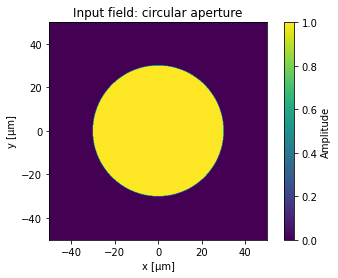

In [9]:
R = np.sqrt(X**2 + Y**2)
aperture = (R < radius).astype(float)

plt.figure()
plt.imshow(aperture, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower")
plt.xlabel("x [µm]")
plt.ylabel("y [µm]")
plt.title("Input field: circular aperture")
plt.colorbar(label="Amplitude")
plt.show()

###  Fresnel propagation formula


#### 1. Multiply by the input quadratic phase

$$
U_0(x,y) \mapsto U_0(x,y)Q_z(x,y)
$$

where

$$
Q_z(x,y)=\exp\left(i k\frac{x^2+y^2}{2z}\right).
$$

This phase comes from the parabolic approximation to the spherical-wave distance.

#### 2. Fourier transform

The Fresnel integral can be written as a Fourier transform evaluated at

$$
f_x = \frac{x_\text{out}}{\lambda z},
\qquad
f_y = \frac{y_\text{out}}{\lambda z}.
$$

Therefore, once the FFT gives us samples at spatial frequencies $f_x,f_y$, the corresponding output-plane coordinates are

$$
x_\text{out}=\lambda z f_x,
\qquad
 y_\text{out}=\lambda z f_y.
$$


For intensity-shape visualization, constant amplitude factors and quadratic output phase do not matter.

In [10]:
# Quadratic phase in the input plane.
Q_in = np.exp(1j * k * (X**2 + Y**2) / (2 * z))

# Excluding the constant factor
propfield = F2d(aperture * Q_in) 

# Output-plane coordinate vector. Notice: this is NOT the same as the input x-vector.
x_out = fx * lambda0 * z

### Visualizing the propagated field

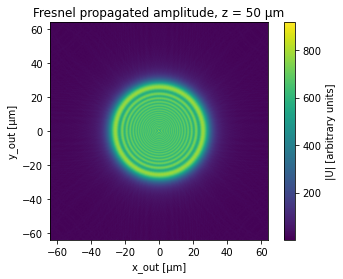

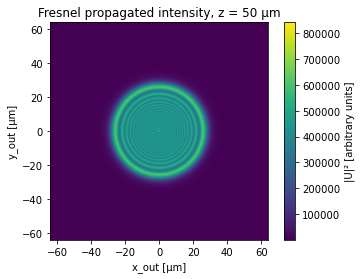

In [12]:
extent_out = [x_out[0]*1e6, x_out[-1]*1e6, x_out[0]*1e6, x_out[-1]*1e6]

amplitude = np.abs(propfield)
intensity = amplitude**2

plt.figure()
plt.imshow(amplitude, extent=extent_out, origin="lower")
plt.xlabel("x_out [µm]")
plt.ylabel("y_out [µm]")
plt.title(f"Fresnel propagated amplitude, z = {z*1e6:.0f} µm")
plt.colorbar(label="|U| [arbitrary units]")
plt.show()

plt.figure()
plt.imshow(intensity, extent=extent_out, origin="lower")
plt.xlabel("x_out [µm]")
plt.ylabel("y_out [µm]")
plt.title(f"Fresnel propagated intensity, z = {z*1e6:.0f} µm")
plt.colorbar(label="|U|² [arbitrary units]")
plt.show()

### Why the output coordinate grid changes with propagation distance

This is one of the most important differences between Fresnel method and the angular spectrum method.

In the angular spectrum method, the output field is sampled on the **same spatial grid** as the input field.

In this Fresnel method, the output coordinate is tied to the Fourier-frequency grid:

$$
x_\text{out}=\lambda z f_x.
$$

Since $f_x$ is fixed by the input sampling, increasing $z$ stretches the output coordinate grid. The diffraction pattern appears to expand physically with propagation distance.

The output pixel pitch is

$$
\Delta x_\text{out}=\lambda z \Delta f=\frac{\lambda z}{L}.
$$

So the output sampling gets coarser as $z$ increases.

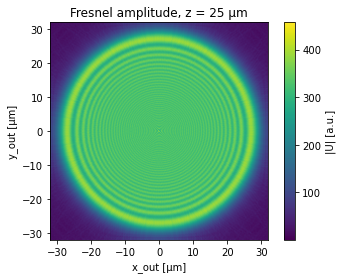

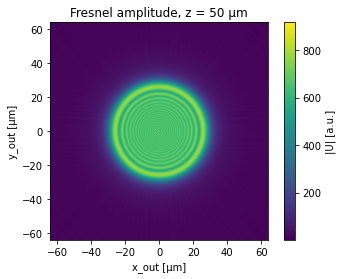

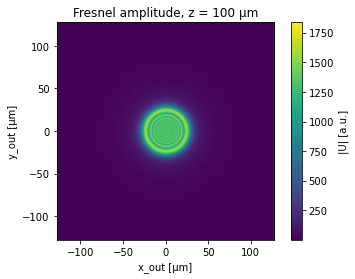

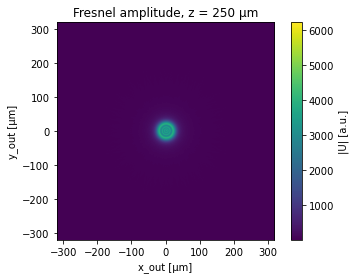

In [16]:
def fresnel_propagate(U0, wavelength, z, dx):
    
    N = U0.shape[0]
    x = (np.arange(N) - N / 2) * dx
    X, Y = np.meshgrid(x, x, indexing="xy")
    fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))

    k = 2 * np.pi / wavelength
    Q_in = np.exp(1j * k * (X**2 + Y**2) / (2 * z))

    U_out = F2d(U0 * Q_in) 
    x_out = fx * wavelength * z
    return U_out, x_out


# Show how the coordinate grid and pattern change with z.
z_values = [25e-6, 50e-6, 100e-6, 250e-6]

for z_i in z_values:
    U_i, x_i = fresnel_propagate(aperture, lambda0, z_i, dx)
    extent_i = [x_i[0]*1e6, x_i[-1]*1e6, x_i[0]*1e6, x_i[-1]*1e6]
    plt.figure()
    plt.imshow(np.abs(U_i), extent=extent_i, origin="lower")
    plt.xlabel("x_out [µm]")
    plt.ylabel("y_out [µm]")
    plt.title(f"Fresnel amplitude, z = {z_i*1e6:.0f} µm")
    plt.colorbar(label="|U| [a.u.]")
    plt.show()

### Physical Fresnel propagation with scaling and phase

For many intensity-only demonstrations, constant amplitude factors and quadratic output phase do not matter. But for phase retrieval, holography, and later ptychography, we should consider the full expression.

A more physical Fresnel propagator is

$$
U_z(x,y)
=
\frac{e^{ikz}}{i\lambda z}
Q_z(x,y)
\iint U_0(x',y') Q_z(x',y')
\exp\left[-i2\pi\left(f_x x' + f_y y'\right)\right] dx' dy'.
$$

Numerically, the integral becomes a sum, so we multiply the FFT by $\Delta x^2$.

The output coordinates are again:

$$
x_\text{out}=\lambda z f_x,\qquad y_\text{out}=\lambda z f_y.
$$

This version preserves the physically meaningful output phase, up to the accuracy of the Fresnel approximation and sampling.

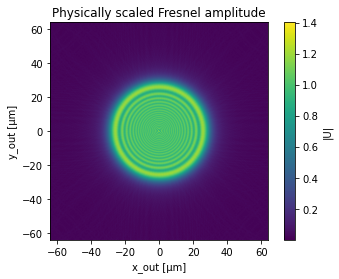

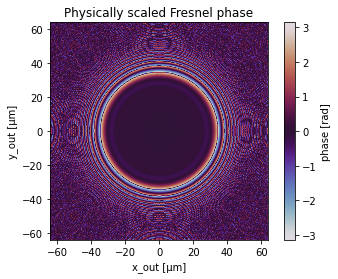

In [14]:
def fresnel_propagate_physical(U0, wavelength, z, dx):
    """Single-FFT Fresnel propagation with physical scaling and output phase.

    This implements:
        U_out = exp(i k z)/(i lambda z) * Q_out * FFT{U0 * Q_in} * dx^2

    The result is sampled on the Fresnel output grid x_out = lambda*z*fx.
    """
    N = U0.shape[0]
    x = (np.arange(N) - N / 2) * dx
    X, Y = np.meshgrid(x, x, indexing="xy")
    fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
    x_out = fx * wavelength * z
    Xout, Yout = np.meshgrid(x_out, x_out, indexing="xy")

    k = 2 * np.pi / wavelength
    Q_in = np.exp(1j * k * (X**2 + Y**2) / (2 * z))
    Q_out = np.exp(1j * k * (Xout**2 + Yout**2) / (2 * z))

    integral_approx = F2d(U0 * Q_in) * dx**2
    U_out = np.exp(1j * k * z) / (1j * wavelength * z) * Q_out * integral_approx
    return U_out, x_out


U_phys, x_phys = fresnel_propagate_physical(aperture, lambda0, z, dx)

plt.figure()
plt.imshow(np.abs(U_phys), extent=[x_phys[0]*1e6, x_phys[-1]*1e6, x_phys[0]*1e6, x_phys[-1]*1e6], origin="lower")
plt.xlabel("x_out [µm]")
plt.ylabel("y_out [µm]")
plt.title("Physically scaled Fresnel amplitude")
plt.colorbar(label="|U|")
plt.show()

plt.figure()
plt.imshow(np.angle(U_phys), extent=[x_phys[0]*1e6, x_phys[-1]*1e6, x_phys[0]*1e6, x_phys[-1]*1e6], origin="lower", cmap="twilight")
plt.xlabel("x_out [µm]")
plt.ylabel("y_out [µm]")
plt.title("Physically scaled Fresnel phase")
plt.colorbar(label="phase [rad]")
plt.show()

### Sampling: when Fresnel propagation becomes unreliable

The Fresnel method contains the quadratic phase factor

$$
Q_z(x,y)=\exp\left(i k\frac{x^2+y^2}{2z}\right).
$$

Its phase is

$$
\phi(x,y)=k\frac{x^2+y^2}{2z}.
$$

For small $z$, this phase oscillates rapidly across the input plane. If the phase changes too much between neighboring pixels, the sampled phase is no longer reliable. Aliasing occurs.

A rough warning sign is when this becomes comparable to $\pi$ or larger.

This is the opposite numerical trend from angular spectrum propagation: in the angular spectrum method, the propagation phase in Fourier space becomes more oscillatory for large $z$; in Fresnel method, the input quadratic phase becomes more oscillatory for small $z$.

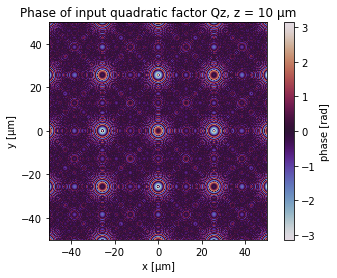

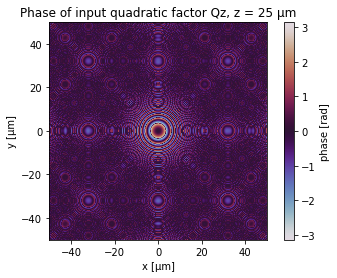

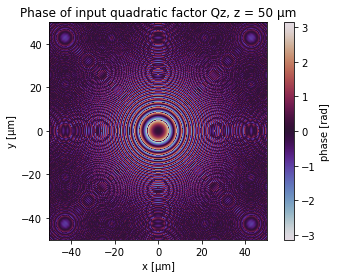

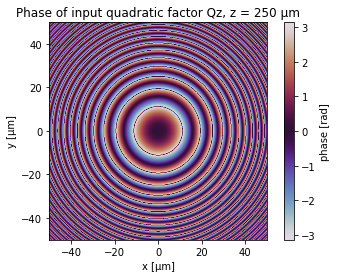

In [15]:
for z_i in [10e-6, 25e-6, 50e-6, 250e-6]:
    Q_i = np.exp(1j * k * (X**2 + Y**2) / (2 * z_i))
    plt.figure()
    plt.imshow(np.angle(Q_i), extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower", cmap="twilight")
    plt.xlabel("x [µm]")
    plt.ylabel("y [µm]")
    plt.title(f"Phase of input quadratic factor Qz, z = {z_i*1e6:.0f} µm")
    plt.colorbar(label="phase [rad]")
    plt.show()